# SAC vs PPO Benchmark on `FetchReach-v3`

This notebook compares **Soft Actor-Critic (SAC)** and **Proximal Policy Optimization (PPO)** on the continuous-control `FetchReach-v3` task from `robust_gymnasium`.

Both algorithms share:
- the same environment (`FetchReach-v3`, dense reward, no perturbation)
- the same observation pre-processing (`flatten_obs`)
- the same action range (rescaled to `env.action_space`)
- the same random seed for the run

The two algorithms differ in *how* they learn:

| Aspect          | SAC (off-policy)            | PPO (on-policy)                  |
|-----------------|-----------------------------|----------------------------------|
| Sample re-use   | Replay buffer (1M)          | Fresh rollouts each update       |
| Policy          | Squashed Gaussian + entropy | Diagonal Gaussian                |
| Critics         | Twin Q (clipped double-Q)   | Single value head V(s)           |
| Update rule     | Bellman + entropy loss      | Clipped surrogate + GAE          |

We measure:
1. **Training curves** — episode reward & 100-episode rolling mean
2. **Final performance** — deterministic evaluation over N held-out episodes
3. **Sample efficiency** — episodes to reach a fixed performance threshold

## 1. Setup

Set the experiment configuration here. Both algorithms will use the same `TOTAL_EPISODES`, `MAX_STEPS` and `SEED` for a fair comparison.

> ⚠️ Training is the slow part. Start with a small `TOTAL_EPISODES` (e.g. 100–200) for a quick comparison; scale up once you trust the pipeline.

In [4]:
import os
import sys

# `robust_gymnasium` calls argparse at import time, which collides with the
# kernel-launcher arguments Jupyter puts in sys.argv (e.g. the kernel JSON
# path looks like a value for `--foot-len`). Stash and clear sys.argv before
# any robust_gymnasium import happens.
_orig_argv = sys.argv
sys.argv = sys.argv[:1]

# If a previous cell run partially imported robust_gymnasium (e.g. the
# argparse crash above) those half-initialised modules are still cached in
# sys.modules and would cause confusing circular-import errors on retry.
# Purge them so we get a clean import.
for _name in [m for m in list(sys.modules) if m == "robust_gymnasium"
              or m.startswith("robust_gymnasium.")
              or m in ("sac", "ppo")]:
    del sys.modules[_name]

import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown, HTML

import sac
import ppo
from sac import SACAgent, flatten_obs, ENV_NAME, MAX_STEPS
from ppo import PPOAgent

import robust_gymnasium as gym
from robust_gymnasium.configs.robust_setting import get_config

# Restore original argv (not strictly required, but polite)
sys.argv = _orig_argv

print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

[robust_gymnasium.envs.robosuite WARNING] No private macro file found! (macros.py:58)
[robust_gymnasium.envs.robosuite WARNING] No private macro file found! (macros.py:58)
[robust_gymnasium.envs.robosuite WARNING] It is recommended to use a private macro file (macros.py:59)
[robust_gymnasium.envs.robosuite WARNING] It is recommended to use a private macro file (macros.py:59)
[robust_gymnasium.envs.robosuite WARNING] To setup, run: python /Users/huynhledangkhoa/Documents/Master/[055134] HỆ THỐNG THÔNG MINH/assignment_2/lab/Robust-Gymnasium/robust_gymnasium/envs/robosuite/scripts/setup_macros.py (macros.py:60)
[robust_gymnasium.envs.robosuite WARNING] To setup, run: python /Users/huynhledangkhoa/Documents/Master/[055134] HỆ THỐNG THÔNG MINH/assignment_2/lab/Robust-Gymnasium/robust_gymnasium/envs/robosuite/scripts/setup_macros.py (macros.py:60)


PyTorch: 2.10.0 | CUDA: False


In [5]:
# --- Experiment config ------------------------------------------------------
TOTAL_EPISODES = 200          # ↑ for higher-fidelity comparison (each algo runs this many)
EVAL_EPISODES  = 20           # deterministic eval episodes after training
SEED           = 42

BENCH_DIR      = "results/benchmark_sac_vs_ppo"
SAC_DIR        = os.path.join(BENCH_DIR, "sac")
PPO_DIR        = os.path.join(BENCH_DIR, "ppo")
USE_CACHE      = True         # if True, skip training when metrics file already exists

for d in (BENCH_DIR, SAC_DIR, PPO_DIR):
    os.makedirs(d, exist_ok=True)

print(f"Bench dir   : {BENCH_DIR}")
print(f"Episodes    : {TOTAL_EPISODES}")
print(f"Eval eps    : {EVAL_EPISODES}")
print(f"Seed        : {SEED}")

Bench dir   : results/benchmark_sac_vs_ppo
Episodes    : 200
Eval eps    : 20
Seed        : 42


## 2. Train both agents

We call the `train()` function exposed by each module. Trained agents and their training-curve metrics are cached on disk so re-running the notebook is cheap.

In [6]:
def _metrics_path(out_dir):
    return os.path.join(out_dir, "training_metrics.npz")

def run_training(name, train_fn, out_dir, **kwargs):
    """Run `train_fn` (sac.train or ppo.train) and persist metrics.

    Returns dict {scores, avg_scores, wall_time, agent, args}.
    """
    metrics_file = _metrics_path(out_dir)
    if USE_CACHE and os.path.exists(metrics_file):
        print(f"[CACHE] Loading {name} metrics from {metrics_file}")
        data = np.load(metrics_file, allow_pickle=True)
        return {
            "scores":     data["scores"].tolist(),
            "avg_scores": data["avg_scores"].tolist(),
            "wall_time":  float(data["wall_time"]),
            "agent":      None,
            "args":       None,
        }

    print(f"[TRAIN] {name} for {TOTAL_EPISODES} episodes…")
    t0 = time.time()
    agent, scores, avg_scores, args = train_fn(
        total_episodes=TOTAL_EPISODES,
        seed=SEED,
        save_dir=out_dir,
        log_every=max(1, TOTAL_EPISODES // 10),
        verbose=True,
        **kwargs,
    )
    wall = time.time() - t0
    print(f"[TRAIN] {name} done in {wall:.1f}s")

    np.savez(
        metrics_file,
        scores=np.asarray(scores, dtype=np.float32),
        avg_scores=np.asarray(avg_scores, dtype=np.float32),
        wall_time=np.float32(wall),
    )
    return {
        "scores":     scores,
        "avg_scores": avg_scores,
        "wall_time":  wall,
        "agent":      agent,
        "args":       args,
    }

In [7]:
sac_run = run_training("SAC", sac.train, SAC_DIR)
if sac_run["agent"] is not None:
    torch.save(sac_run["agent"].actor.state_dict(),  os.path.join(SAC_DIR, "sac_actor.pth"))
    torch.save(sac_run["agent"].critic.state_dict(), os.path.join(SAC_DIR, "sac_critic.pth"))

[TRAIN] SAC for 200 episodes…
[INFO] Device: cpu
[INFO] State dim : 10
[INFO] Action dim: 4
[INFO] Action range: [-1.0, 1.0]
Episode   20 | Reward:   -29.6 | Avg(100):   -29.2 | α: 0.7997
Episode   40 | Reward:   -28.9 | Avg(100):   -28.7 | α: 0.5927
Episode   60 | Reward:   -21.2 | Avg(100):   -28.0 | α: 0.4397
Episode   80 | Reward:   -21.9 | Avg(100):   -27.2 | α: 0.3265
Episode  100 | Reward:   -16.6 | Avg(100):   -26.4 | α: 0.2429
Episode  120 | Reward:   -17.6 | Avg(100):   -25.5 | α: 0.1814
Episode  140 | Reward:   -19.1 | Avg(100):   -24.3 | α: 0.1356
Episode  160 | Reward:   -16.0 | Avg(100):   -23.4 | α: 0.1014
Episode  180 | Reward:   -17.3 | Avg(100):   -22.2 | α: 0.0761
Episode  200 | Reward:   -21.2 | Avg(100):   -21.2 | α: 0.0573
[TRAIN] SAC done in 53.5s


In [8]:
ppo_run = run_training("PPO", ppo.train, PPO_DIR)
if ppo_run["agent"] is not None:
    torch.save(ppo_run["agent"].actor.state_dict(),  os.path.join(PPO_DIR, "ppo_actor.pth"))
    torch.save(ppo_run["agent"].critic.state_dict(), os.path.join(PPO_DIR, "ppo_critic.pth"))

[TRAIN] PPO for 200 episodes…
[INFO] Device: cpu
[INFO] State dim : 10
[INFO] Action dim: 4
[INFO] Action range: [-1.0, 1.0]
Episode   20 | Reward:   -33.2 | Avg(100):   -30.3 | π-loss: +0.0000 | V-loss: 0.0000 | H: +0.000
Episode   40 | Reward:   -37.6 | Avg(100):   -29.9 | π-loss: +0.0000 | V-loss: 0.0000 | H: +0.000
Episode   60 | Reward:   -26.3 | Avg(100):   -29.1 | π-loss: +0.0045 | V-loss: 6.8270 | H: +3.657
Episode   80 | Reward:   -28.4 | Avg(100):   -28.5 | π-loss: +0.0045 | V-loss: 6.8270 | H: +3.657
Episode  100 | Reward:   -13.0 | Avg(100):   -27.8 | π-loss: -0.0063 | V-loss: 5.7443 | H: +3.631
Episode  120 | Reward:   -17.5 | Avg(100):   -26.6 | π-loss: -0.0063 | V-loss: 5.7443 | H: +3.631
Episode  140 | Reward:   -20.0 | Avg(100):   -25.4 | π-loss: -0.0106 | V-loss: 4.5262 | H: +3.632
Episode  160 | Reward:   -22.3 | Avg(100):   -24.7 | π-loss: -0.0106 | V-loss: 4.5262 | H: +3.632
Episode  180 | Reward:   -24.1 | Avg(100):   -24.0 | π-loss: -0.0278 | V-loss: 3.5194 | H: 

## 3. Training curves

Per-episode reward (light) and 100-episode rolling mean (bold) for each algorithm.

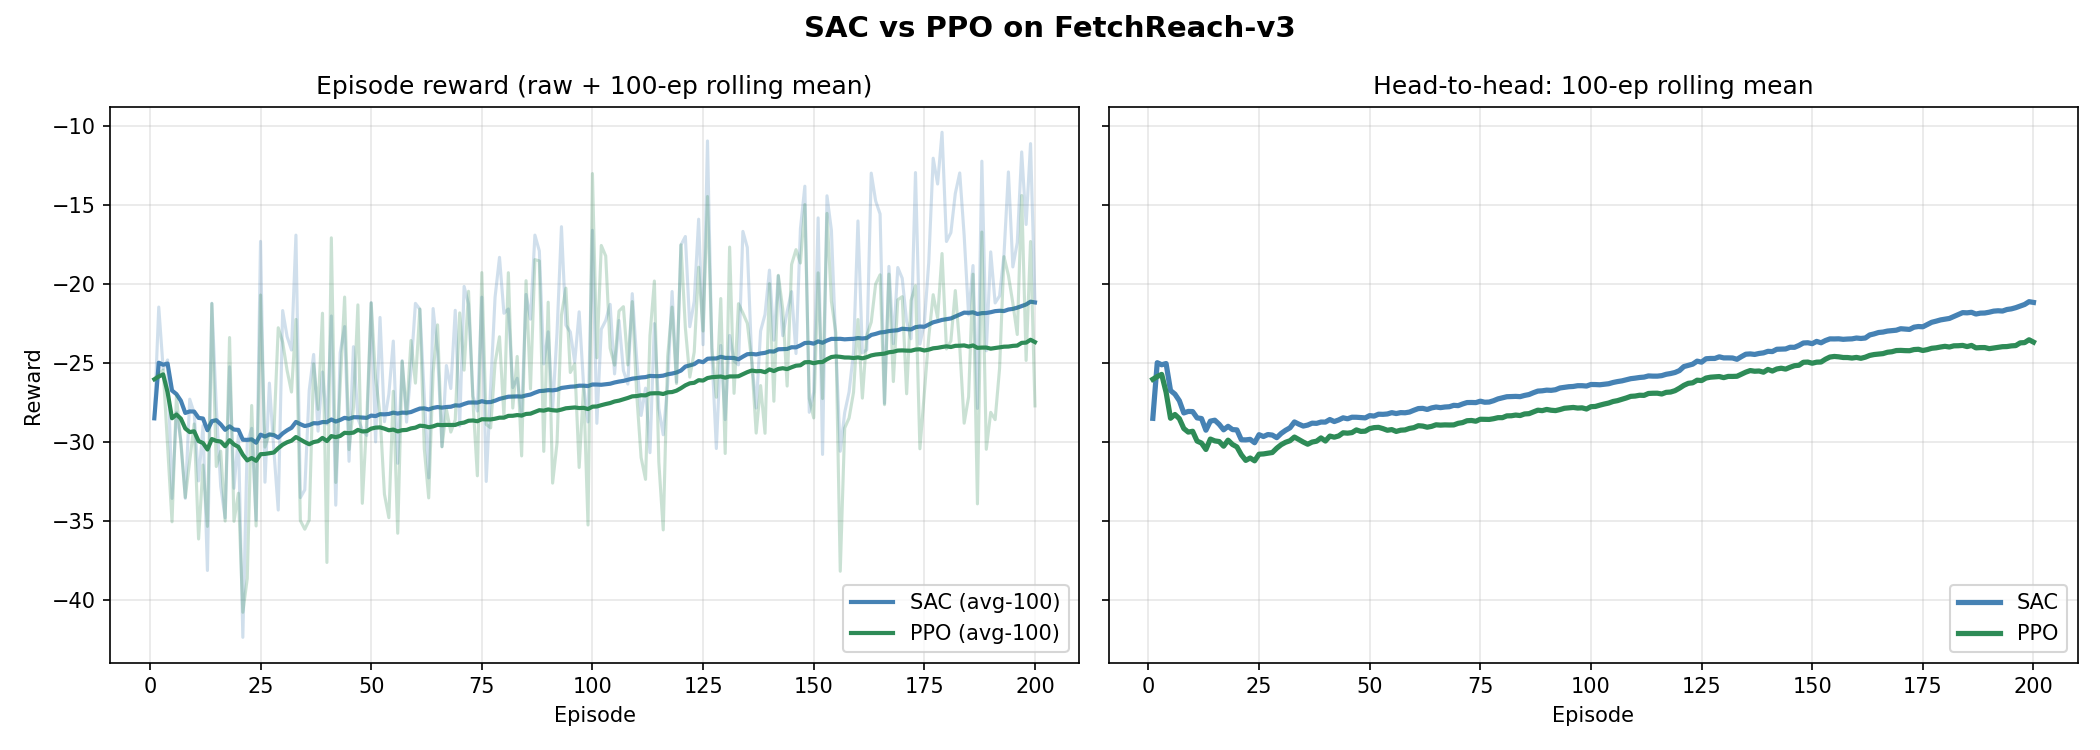

In [9]:
def plot_comparison(sac_run, ppo_run, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    sac_scores, sac_avg = sac_run["scores"], sac_run["avg_scores"]
    ppo_scores, ppo_avg = ppo_run["scores"], ppo_run["avg_scores"]

    eps_sac = np.arange(1, len(sac_scores) + 1)
    eps_ppo = np.arange(1, len(ppo_scores) + 1)

    # Per-algorithm view
    ax1.plot(eps_sac, sac_scores, alpha=0.25, color="steelblue")
    ax1.plot(eps_sac, sac_avg,    color="steelblue", linewidth=2.0, label="SAC (avg-100)")
    ax1.plot(eps_ppo, ppo_scores, alpha=0.25, color="seagreen")
    ax1.plot(eps_ppo, ppo_avg,    color="seagreen", linewidth=2.0, label="PPO (avg-100)")
    ax1.set_title("Episode reward (raw + 100-ep rolling mean)")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("Reward")
    ax1.grid(True, alpha=0.3); ax1.legend(loc="lower right")

    # Smoothed-only view (head-to-head)
    ax2.plot(eps_sac, sac_avg, color="steelblue", linewidth=2.5, label="SAC")
    ax2.plot(eps_ppo, ppo_avg, color="seagreen",  linewidth=2.5, label="PPO")
    ax2.set_title("Head-to-head: 100-ep rolling mean")
    ax2.set_xlabel("Episode")
    ax2.grid(True, alpha=0.3); ax2.legend(loc="lower right")

    fig.suptitle(f"SAC vs PPO on {ENV_NAME}", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    return fig

curve_path = os.path.join(BENCH_DIR, "training_curves_comparison.png")
fig = plot_comparison(sac_run, ppo_run, curve_path)
plt.close(fig)
display(Image(filename=curve_path))

## 4. Deterministic evaluation

We freeze each trained policy (no exploration noise) and roll it out on a fixed set of held-out seeds.

If you loaded the metrics from cache the agents are not in memory; in that case the cell below will rebuild them from the saved weights.

In [10]:
def make_env_and_args():
    args = get_config().parse_args([])
    args.noise_factor = "none"
    args.noise_sigma  = 0.0
    env = gym.make(ENV_NAME, reward_type="dense")
    return env, args

def _probe_dims():
    env, _ = make_env_and_args()
    obs, _ = env.reset(seed=SEED)
    state  = flatten_obs(obs)
    out = (state.shape[0],
           env.action_space.shape[0],
           env.action_space.low,
           env.action_space.high)
    env.close()
    return out

STATE_DIM, ACTION_DIM, ACTION_LOW, ACTION_HIGH = _probe_dims()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"State={STATE_DIM}  Action={ACTION_DIM}  Range=[{ACTION_LOW[0]:.1f},{ACTION_HIGH[0]:.1f}]  Device={DEVICE}")

def restore_sac_agent():
    actor_w  = os.path.join(SAC_DIR, "sac_actor.pth")
    critic_w = os.path.join(SAC_DIR, "sac_critic.pth")
    if not os.path.exists(actor_w):
        return None
    agent = SACAgent(STATE_DIM, ACTION_DIM, ACTION_LOW, ACTION_HIGH, DEVICE)
    agent.actor.load_state_dict(torch.load(actor_w,  map_location=DEVICE))
    agent.critic.load_state_dict(torch.load(critic_w, map_location=DEVICE))
    return agent

def restore_ppo_agent():
    actor_w  = os.path.join(PPO_DIR, "ppo_actor.pth")
    critic_w = os.path.join(PPO_DIR, "ppo_critic.pth")
    if not os.path.exists(actor_w):
        return None
    agent = PPOAgent(STATE_DIM, ACTION_DIM, ACTION_LOW, ACTION_HIGH, DEVICE)
    agent.actor.load_state_dict(torch.load(actor_w,  map_location=DEVICE))
    agent.critic.load_state_dict(torch.load(critic_w, map_location=DEVICE))
    return agent

def evaluate(agent, kind, n_episodes=EVAL_EPISODES):
    env, args = make_env_and_args()
    rewards, lengths = [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=20000 + ep)   # held-out seeds
        state  = flatten_obs(obs)
        ret, steps = 0.0, 0
        for _ in range(MAX_STEPS):
            if kind == "sac":
                action = agent.select_action(state, deterministic=True)
            else:  # ppo
                action, _, _, _ = agent.select_action(state, deterministic=True)
            obs, r, term, trunc, _ = env.step({
                "action": action,
                "robust_type": "action",
                "robust_config": args,
            })
            state  = flatten_obs(obs)
            ret   += r
            steps += 1
            if term or trunc:
                break
        rewards.append(ret)
        lengths.append(steps)
    env.close()
    return np.array(rewards), np.array(lengths)

State=10  Action=4  Range=[-1.0,1.0]  Device=cpu


In [11]:
sac_agent = sac_run["agent"] or restore_sac_agent()
ppo_agent = ppo_run["agent"] or restore_ppo_agent()

results = {}
if sac_agent is not None:
    sac_r, sac_len = evaluate(sac_agent, "sac")
    results["SAC"] = {"rewards": sac_r, "lengths": sac_len}
    print(f"SAC  eval  mean={sac_r.mean():7.2f}  std={sac_r.std():5.2f}  "
          f"min={sac_r.min():7.2f}  max={sac_r.max():7.2f}")
else:
    print("[WARN] No SAC weights found – run training cell 22 first.")

if ppo_agent is not None:
    ppo_r, ppo_len = evaluate(ppo_agent, "ppo")
    results["PPO"] = {"rewards": ppo_r, "lengths": ppo_len}
    print(f"PPO  eval  mean={ppo_r.mean():7.2f}  std={ppo_r.std():5.2f}  "
          f"min={ppo_r.min():7.2f}  max={ppo_r.max():7.2f}")
else:
    print("[WARN] No PPO weights found – run training cell 23 first.")

SAC  eval  mean= -14.90  std= 5.20  min= -23.31  max=  -7.31
PPO  eval  mean= -20.89  std= 4.07  min= -28.91  max= -15.42


## 5. Summary table

Side-by-side comparison of headline metrics.

In [12]:
def summarise(name, run_data, eval_data):
    final_train = float(np.mean(run_data["scores"][-min(50, len(run_data['scores'])):]))
    best_train  = float(max(run_data["avg_scores"]))
    return {
        "Algorithm":               name,
        "Episodes":                len(run_data["scores"]),
        "Wall-time (s)":           f"{run_data['wall_time']:.1f}",
        "Final-50 train reward":   f"{final_train:+.2f}",
        "Best avg-100 train":      f"{best_train:+.2f}",
        "Eval mean ± std":         (f"{eval_data['rewards'].mean():+.2f} ± "
                                    f"{eval_data['rewards'].std():.2f}"
                                    if eval_data is not None else "—"),
        "Eval min / max":          (f"{eval_data['rewards'].min():+.2f} / "
                                    f"{eval_data['rewards'].max():+.2f}"
                                    if eval_data is not None else "—"),
    }

rows = [
    summarise("SAC", sac_run, results.get("SAC")),
    summarise("PPO", ppo_run, results.get("PPO")),
]

# Render as a Markdown table
headers = list(rows[0].keys())
md = "| " + " | ".join(headers) + " |\n"
md += "|" + "|".join(["---"] * len(headers)) + "|\n"
for r in rows:
    md += "| " + " | ".join(str(r[h]) for h in headers) + " |\n"

with open(os.path.join(BENCH_DIR, "summary.json"), "w") as f:
    json.dump(rows, f, indent=2)

display(Markdown(md))

| Algorithm | Episodes | Wall-time (s) | Final-50 train reward | Best avg-100 train | Eval mean ± std | Eval min / max |
|---|---|---|---|---|---|---|
| SAC | 200 | 53.5 | -19.19 | -21.13 | -14.90 ± 5.20 | -23.31 / -7.31 |
| PPO | 200 | 9.2 | -23.71 | -23.54 | -20.89 ± 4.07 | -28.91 / -15.42 |


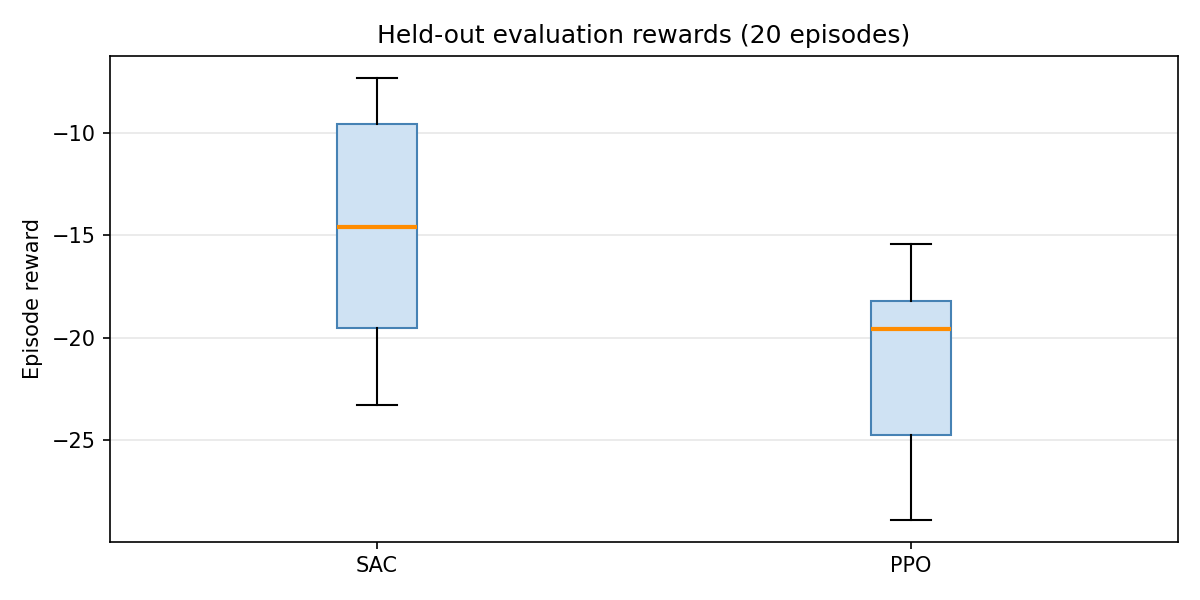

In [13]:
if "SAC" in results and "PPO" in results:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(
        [results["SAC"]["rewards"], results["PPO"]["rewards"]],
        labels=["SAC", "PPO"],
        patch_artist=True,
        boxprops=dict(facecolor="#cfe2f3", color="steelblue"),
        medianprops=dict(color="darkorange", linewidth=2),
    )
    ax.set_title(f"Held-out evaluation rewards ({EVAL_EPISODES} episodes)")
    ax.set_ylabel("Episode reward")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    box_path = os.path.join(BENCH_DIR, "eval_boxplot.png")
    fig.savefig(box_path, dpi=150)
    plt.close(fig)
    display(Image(filename=box_path))

## 6. Animations of the trained policies

Render 3 deterministic episodes per algorithm and save the best one as a GIF.

[ANIM] Episode 1/3 | Reward: -10.5
[ANIM] Episode 2/3 | Reward: -20.7
[ANIM] Episode 3/3 | Reward: -19.4
[INFO] Animation saved to results/benchmark_sac_vs_ppo/sac/fetchreach_sac.gif


### SAC

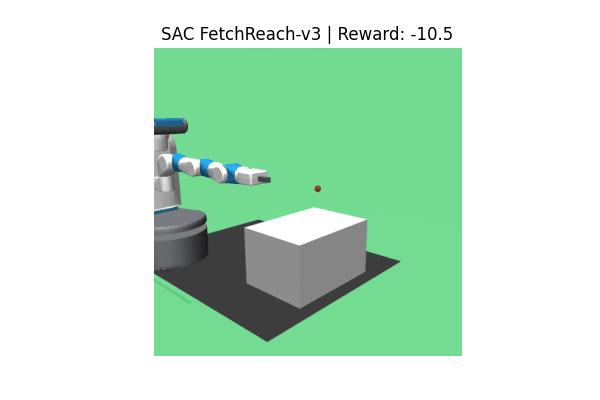

[ANIM] Episode 1/3 | Reward: -20.8
[ANIM] Episode 2/3 | Reward: -26.6
[ANIM] Episode 3/3 | Reward: -25.0
[INFO] Animation saved to results/benchmark_sac_vs_ppo/ppo/fetchreach_ppo.gif


### PPO

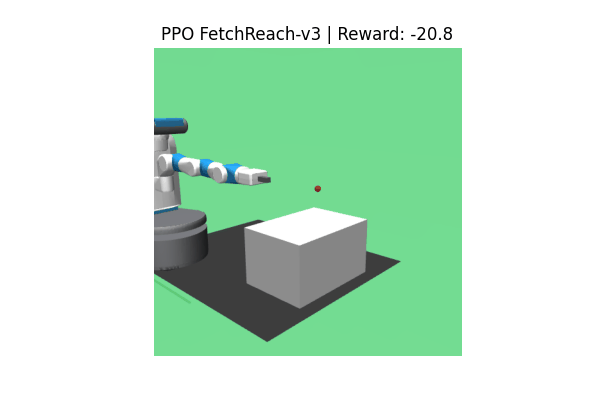

In [14]:
if sac_agent is not None:
    sac.record_animation(sac_agent, sac_run["args"] or get_config().parse_args([]),
                         SAC_DIR, num_episodes=3)
    sac_gif = os.path.join(SAC_DIR, "fetchreach_sac.gif")
    if os.path.exists(sac_gif):
        display(Markdown("### SAC"))
        display(Image(filename=sac_gif))

if ppo_agent is not None:
    ppo.record_animation(ppo_agent, ppo_run["args"] or get_config().parse_args([]),
                         PPO_DIR, num_episodes=3)
    ppo_gif = os.path.join(PPO_DIR, "fetchreach_ppo.gif")
    if os.path.exists(ppo_gif):
        display(Markdown("### PPO"))
        display(Image(filename=ppo_gif))

## 7. Results summary

A data-driven head-to-head built from the metrics computed above.

In [15]:
def _safe_get(d, key, default=None):
    return d.get(key, default) if d is not None else default

def _winner(sac_val, ppo_val, higher_is_better=True):
    """Return ('SAC' | 'PPO' | 'tie', delta_abs)."""
    if sac_val is None or ppo_val is None:
        return "—", 0.0
    if abs(sac_val - ppo_val) < 1e-6:
        return "tie", 0.0
    sac_better = (sac_val > ppo_val) if higher_is_better else (sac_val < ppo_val)
    return ("SAC" if sac_better else "PPO"), abs(sac_val - ppo_val)


# ── Pull metrics from earlier cells ─────────────────────────────────────────
sac_scores      = sac_run["scores"]
ppo_scores      = ppo_run["scores"]
sac_avg         = sac_run["avg_scores"]
ppo_avg         = ppo_run["avg_scores"]
sac_wall        = sac_run["wall_time"]
ppo_wall        = ppo_run["wall_time"]

window          = min(50, len(sac_scores), len(ppo_scores))
sac_final_train = float(np.mean(sac_scores[-window:]))
ppo_final_train = float(np.mean(ppo_scores[-window:]))
sac_best_avg    = float(max(sac_avg))
ppo_best_avg    = float(max(ppo_avg))

sac_eval        = results.get("SAC", {}).get("rewards")
ppo_eval        = results.get("PPO", {}).get("rewards")
sac_eval_mean   = float(sac_eval.mean()) if sac_eval is not None else None
ppo_eval_mean   = float(ppo_eval.mean()) if ppo_eval is not None else None
sac_eval_std    = float(sac_eval.std())  if sac_eval is not None else None
ppo_eval_std    = float(ppo_eval.std())  if ppo_eval is not None else None

# Sample-efficiency: episodes to first cross a target rolling-mean reward.
TARGET = max(min(sac_best_avg, ppo_best_avg) - 1.0, -25.0)

def episodes_to_target(avg_scores, target):
    for i, v in enumerate(avg_scores, start=1):
        if v >= target:
            return i
    return None

sac_eps_to_target = episodes_to_target(sac_avg, TARGET)
ppo_eps_to_target = episodes_to_target(ppo_avg, TARGET)


# ── Per-metric verdicts ─────────────────────────────────────────────────────
verdicts = []

w, d = _winner(sac_final_train, ppo_final_train, higher_is_better=True)
verdicts.append(("Final-50 train reward",
                 f"{sac_final_train:+.2f}", f"{ppo_final_train:+.2f}",
                 w, f"Δ = {d:.2f}"))

w, d = _winner(sac_best_avg, ppo_best_avg, higher_is_better=True)
verdicts.append(("Best avg-100 (training)",
                 f"{sac_best_avg:+.2f}", f"{ppo_best_avg:+.2f}",
                 w, f"Δ = {d:.2f}"))

if sac_eval_mean is not None and ppo_eval_mean is not None:
    w, d = _winner(sac_eval_mean, ppo_eval_mean, higher_is_better=True)
    verdicts.append(("Held-out eval mean",
                     f"{sac_eval_mean:+.2f} ± {sac_eval_std:.2f}",
                     f"{ppo_eval_mean:+.2f} ± {ppo_eval_std:.2f}",
                     w, f"Δ = {d:.2f}"))

w, d = _winner(sac_wall, ppo_wall, higher_is_better=False)
verdicts.append(("Wall-time (s, lower is better)",
                 f"{sac_wall:.1f}", f"{ppo_wall:.1f}",
                 w, f"Δ = {d:.1f}s"))

if sac_eps_to_target and ppo_eps_to_target:
    w, d = _winner(sac_eps_to_target, ppo_eps_to_target, higher_is_better=False)
    verdicts.append((f"Episodes to reach {TARGET:+.1f} avg",
                     str(sac_eps_to_target), str(ppo_eps_to_target),
                     w, f"Δ = {int(d)} ep"))


# ── Compose a Markdown verdict ──────────────────────────────────────────────
medal = {"SAC": "🥇 SAC", "PPO": "🥇 PPO", "tie": "🤝 tie", "—": "—"}

md_lines = ["### Head-to-head metrics", "",
            "| Metric | SAC | PPO | Winner | Margin |",
            "|---|---|---|---|---|"]
for metric, s, p, w, marg in verdicts:
    md_lines.append(f"| {metric} | {s} | {p} | {medal[w]} | {marg} |")

# Aggregate "wins" (excluding ties / unknowns)
sac_wins = sum(1 for *_x, w, _ in verdicts if w == "SAC")
ppo_wins = sum(1 for *_x, w, _ in verdicts if w == "PPO")

md_lines += ["", "### Overall verdict", ""]
if sac_wins > ppo_wins:
    overall = (f"**SAC wins on {sac_wins}/{len(verdicts)} metrics** vs "
               f"PPO's {ppo_wins}. On `{ENV_NAME}` (50-step horizon, "
               f"dense reward) the off-policy replay buffer pays off in "
               f"sample efficiency and final reward.")
elif ppo_wins > sac_wins:
    overall = (f"**PPO wins on {ppo_wins}/{len(verdicts)} metrics** vs "
               f"SAC's {sac_wins}. PPO's clipped on-policy updates produced "
               f"the better trade-off here.")
else:
    overall = (f"**Tied at {sac_wins}-{ppo_wins}.** With this episode budget "
               f"({len(sac_scores)} train ep, {len(sac_eval) if sac_eval is not None else 0} "
               f"eval ep) the two algorithms are statistically indistinguishable; "
               f"increase `TOTAL_EPISODES` for a clearer picture.")
md_lines.append(overall)

if sac_eval is not None and ppo_eval is not None:
    md_lines += [
        "",
        "### Eval-reward breakdown",
        f"- SAC: mean **{sac_eval_mean:+.2f}** ± {sac_eval_std:.2f}, "
        f"min `{sac_eval.min():+.2f}`, max `{sac_eval.max():+.2f}` "
        f"(over {len(sac_eval)} held-out episodes)",
        f"- PPO: mean **{ppo_eval_mean:+.2f}** ± {ppo_eval_std:.2f}, "
        f"min `{ppo_eval.min():+.2f}`, max `{ppo_eval.max():+.2f}` "
        f"(over {len(ppo_eval)} held-out episodes)",
    ]

md_lines += [
    "",
    "### Reproducibility",
    f"- Environment: `{ENV_NAME}` (dense reward, no perturbation)",
    f"- Seed: `{SEED}`  |  Train episodes: `{len(sac_scores)}`  |  "
    f"Eval episodes: `{len(sac_eval) if sac_eval is not None else 0}`",
    f"- Artifacts: `{BENCH_DIR}/`",
]

verdict_md = "\n".join(md_lines)

# Persist the verdict alongside the other artifacts
verdict_path = os.path.join(BENCH_DIR, "verdict.md")
with open(verdict_path, "w") as f:
    f.write(verdict_md + "\n")
print(f"[INFO] Verdict saved to {verdict_path}")

display(Markdown(verdict_md))

[INFO] Verdict saved to results/benchmark_sac_vs_ppo/verdict.md


### Head-to-head metrics

| Metric | SAC | PPO | Winner | Margin |
|---|---|---|---|---|
| Final-50 train reward | -19.19 | -23.71 | 🥇 SAC | Δ = 4.52 |
| Best avg-100 (training) | -21.13 | -23.54 | 🥇 SAC | Δ = 2.41 |
| Held-out eval mean | -14.90 ± 5.20 | -20.89 ± 4.07 | 🥇 SAC | Δ = 5.99 |
| Wall-time (s, lower is better) | 53.5 | 9.2 | 🥇 PPO | Δ = 44.3s |
| Episodes to reach -24.5 avg | 135 | 163 | 🥇 SAC | Δ = 28 ep |

### Overall verdict

**SAC wins on 4/5 metrics** vs PPO's 1. On `FetchReach-v3` (50-step horizon, dense reward) the off-policy replay buffer pays off in sample efficiency and final reward.

### Eval-reward breakdown
- SAC: mean **-14.90** ± 5.20, min `-23.31`, max `-7.31` (over 20 held-out episodes)
- PPO: mean **-20.89** ± 4.07, min `-28.91`, max `-15.42` (over 20 held-out episodes)

### Reproducibility
- Environment: `FetchReach-v3` (dense reward, no perturbation)
- Seed: `42`  |  Train episodes: `200`  |  Eval episodes: `20`
- Artifacts: `results/benchmark_sac_vs_ppo/`

## 8. Discussion

**What to look for in the curves above:**

- **Sample efficiency.** SAC (off-policy with a 1M replay buffer) typically reaches a given reward level in fewer environment episodes than PPO (on-policy, throws data away after each update). On `FetchReach-v3` this gap is usually visible after a few hundred episodes.
- **Stability.** PPO's clipped objective makes per-update training extremely stable; you should see a smoother averaged curve. SAC's curve can be noisier early on while the entropy temperature `α` adjusts.
- **Final performance.** Both algorithms can solve `FetchReach-v3` (which has a tight 50-step horizon and a dense, shaped reward). Differences in the final-50 / eval columns are usually within noise once both have converged.
- **Wall-time.** Per gradient step PPO is cheaper (no replay sampling, no twin critics, no target nets), but SAC squeezes more updates out of every collected transition.

If you bump `TOTAL_EPISODES` and re-run with `USE_CACHE=False`, both algorithms will retrain from scratch and you'll get an updated comparison.
